<h1>Data Visualization with the OOP Artist layer in Matplotlib</h1>

In [1]:
from pyodide.http import pyfetch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

<ipython-input-1-693a0ae5716a>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
pd.set_option("display.max_columns", None)

In [3]:
async def download(url, filename):
    response = await pyfetch(url)
    try:
        if response.status == 200:
            data = await response.bytes()
            with open(filename, "wb") as f:
                f.write(data)
                print(f"{filename} successfully downloded")
    except Exception as e:
        print(f"Error: {e}")

In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv"
await download(url, "Canada_data.csv")

Canada_data.csv successfully downloded


In [5]:

df = pd.read_csv("Canada_data.csv")
df.head()

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,741,828,1076,1028,1378,1170,713,858,1537,2212,2555,1999,2395,3326,4067,3697,3479,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,2,2,3,3,21,56,96,71,63,113,307,574,1264,1816,1602,1021,853,1450,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,132,242,434,491,872,795,717,595,1106,2054,1842,2292,2389,2867,3418,3406,3072,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,1,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,0,0,0,3,0,1,0,0,0,0,0,2,0,0,1,0,2,0,0,1,1,0,0,0,0,1,1,15


In [6]:
years = list(map(str, range(1980,2014)))
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

<h2>Line Graph of Total Immigration by Year</h2>

In [7]:
df_TotByYear = df.loc[:,"1980": "2013"].sum(axis = 0)
df_TotByYear = df.loc[:,"1980": "2013"].sum(axis = 0)
df_TotByYear.index = df_TotByYear.index.astype(int)

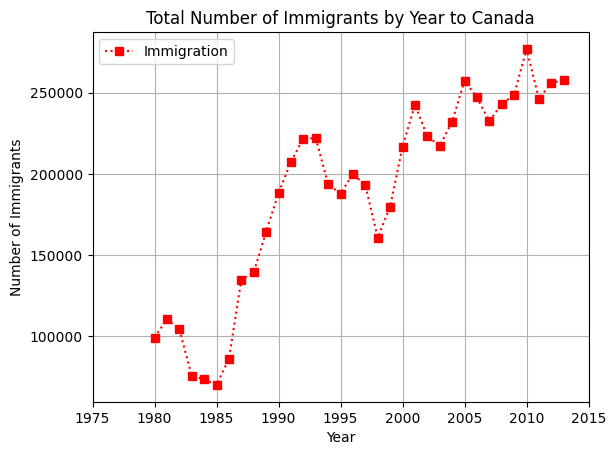

In [8]:
fig, ax = plt.subplots()
ax.plot(df_TotByYear, marker = "s", markersize = 6, color = "red", linestyle = "dotted")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Immigrants")
ax.set_title("Total Number of Immigrants by Year to Canada")
ax.legend(["Immigration"])
ax.set_xlim(1975, 2015)
ax.grid()
plt.show()

<h2>Plot a line graph of immigration from Haiti</h2>

In [9]:
df_haiti = df.loc[df["Country"] == "Haiti", "1980":"2013"]
df_haiti

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
75,1666,3692,3498,2860,1418,1321,1753,2132,1829,2377,2379,2829,2399,3655,2100,2014,1955,1645,1295,1439,1631,2433,2174,1930,1652,1682,1619,1598,2491,2080,4744,6503,5868,4152


In [10]:
df_haiti_t = df_haiti.transpose()
df_haiti_t = df_haiti_t.rename(columns={75: "total"})
df_haiti_t.index = df_haiti_t.index.astype(int)
df_haiti_t

,total
1980,1666
1981,3692
1982,3498
1983,2860
1984,1418
1985,1321
1986,1753
1987,2132
1988,1829
1989,2377


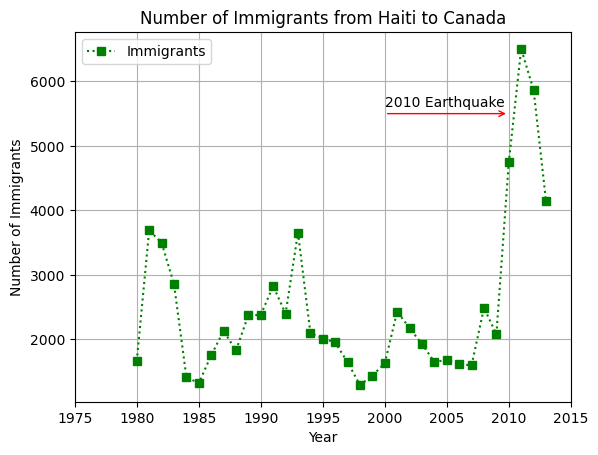

In [11]:
fig, ax = plt.subplots()
ax.plot(df_haiti_t, marker = "s", markersize = "6", color = "green", linestyle = "dotted")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Immigrants")
ax.set_title("Number of Immigrants from Haiti to Canada")
ax.legend(["Immigrants"])
ax.set_xlim(1975,2015)
ax.annotate("",xytext = (2000,5500),xy = (2010, 5500), xycoords = "data",arrowprops = dict(arrowstyle = "->", color = "red"))
ax.annotate("2010 Earthquake", xy = (2000,5600))
plt.grid(True)
plt.show()

<h2>Scatter Plot</h2>

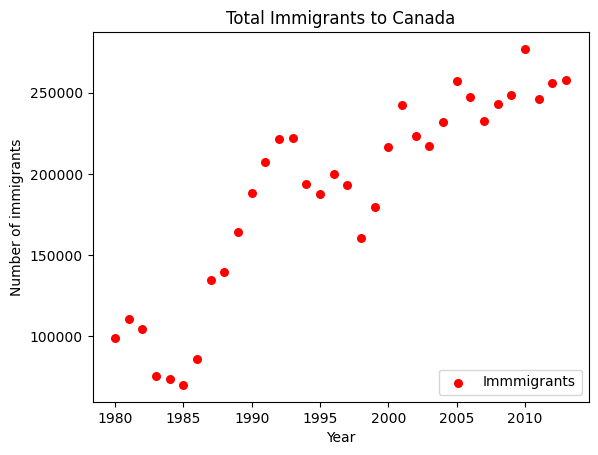

In [12]:
fig, ax = plt.subplots()

ax.scatter(df_TotByYear.index, df_TotByYear, marker = "o", s = 30, color ="red")
ax.set_xlabel("Year")
ax.set_ylabel("Number of immigrants")
ax.set_title("Total Immigrants to Canada")
ax.legend(["Immmigrants"], loc = "lower right")
plt.show()



<h2>Bar Plot</h2>

['India', 'China', 'UK', 'Philippines', 'Pakistan']


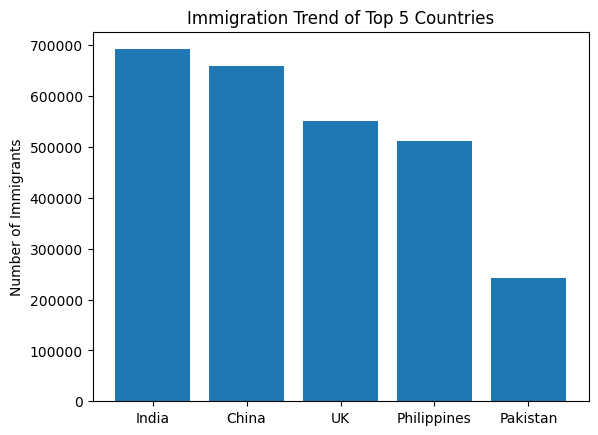

In [13]:
df_top5 = df.sort_values(by = "Total", ascending = False).head()
df_top5 = df_top5[["Country", "Total"]]
df_top5.set_index("Country", inplace = True)

labels = list(df_top5.index)
labels[2] = "UK"
print(labels)

fig, ax = plt.subplots()
ax.bar(labels, df_top5["Total"])

ax.set_title('Immigration Trend of Top 5 Countries')
ax.set_ylabel('Number of Immigrants')


plt.show()

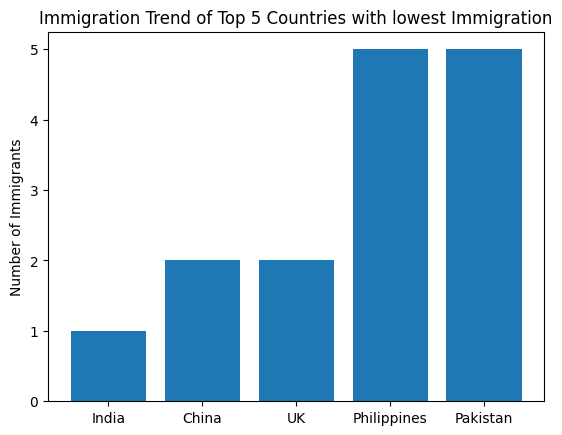

In [14]:
df_top5 = df.sort_values(by = "Total", ascending = True).head()
df_top5 = df_top5[["Country", "Total"]]
df_top5.set_index("Country", inplace = True)

fig, ax = plt.subplots()
ax.bar(labels, df_top5["Total"])

ax.set_title('Immigration Trend of Top 5 Countries with lowest Immigration')
ax.set_ylabel('Number of Immigrants')

plt.show()

<h2>Histogram</h2>

<p>new immigrants from the various countries to Canada in 2013</p>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


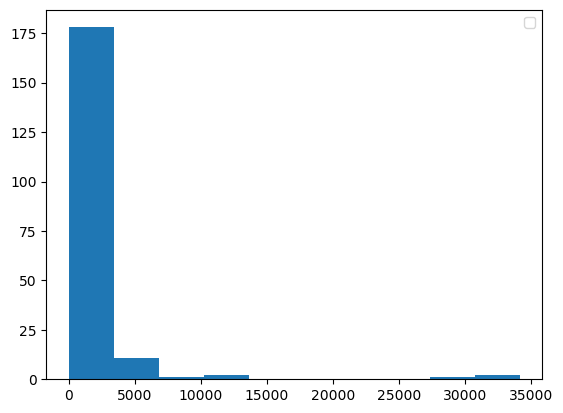

In [15]:
df_all_2013 = df[["Country","2013"]]

fig, ax = plt.subplots()
ax.hist(df_all_2013["2013"])
ax.legend()

In [16]:
df_t = df.set_index("Country")
df_3 = df_t.loc[["Norway", "Denmark", "Sweden"], "1980":"2013"].transpose()
df_3

Country,Norway,Denmark,Sweden
1980,116,272,281
1981,77,293,308
1982,106,299,222
1983,51,106,176
1984,31,93,128
1985,54,73,158
1986,56,93,187
1987,80,109,198
1988,73,129,171
1989,76,129,182


Text(0.5, 1.0, 'distibution of the number of immigrants by number of years')

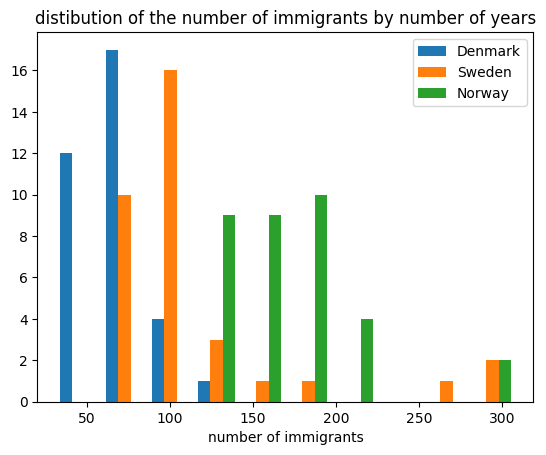

In [17]:
fig, ax = plt.subplots()
ax.hist(df_3)
ax.legend(["Denmark", "Sweden", "Norway"])
ax.set_xlabel("number of immigrants")
ax.set_title("distibution of the number of immigrants by number of years")

<p>immigration distribution for China and India for years 2000 to 2013</p>

In [18]:

df_2 = df_t.loc[["India", "China"], "2000":"2013"].transpose()
df_2

Country,India,China
2000,28572,35529
2001,31223,36434
2002,31889,31961
2003,27155,36439
2004,28235,36619
2005,36210,42584
2006,33848,33518
2007,28742,27642
2008,28261,30037
2009,29456,29622


Text(0.5, 1.0, 'distibution of the number of immigrants by number of years')

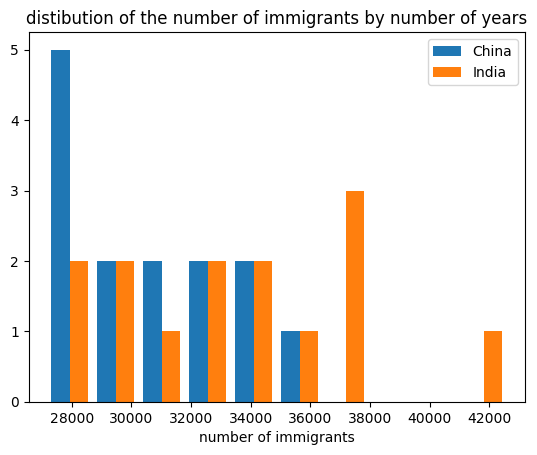

In [19]:
fig, ax = plt.subplots()
ax.hist(df_2)
ax.legend(["China", "India"])
ax.set_xlabel("number of immigrants")
ax.set_title("distibution of the number of immigrants by number of years")

<h2>Pie Charts </h2>

In [53]:
years_int = list(range(1980,1985))
years = list(map(str, years_int))
years

['1980', '1981', '1982', '1983', '1984']

In [54]:
df_total = df[years].sum(axis = 0)
df_total.head()

1980     99137
1981    110563
1982    104271
1983     75550
1984     73417
dtype: int64

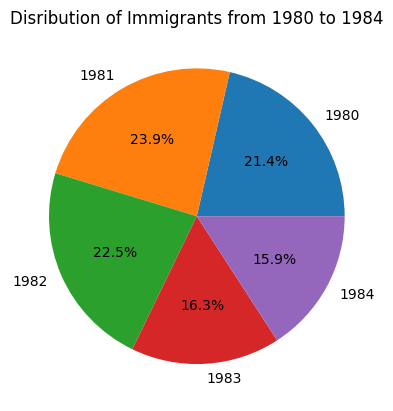

In [56]:
fig, ax = plt.subplots()

ax.pie(df_total, labels = years, autopct = "%1.1f%%")
plt.title("Disribution of Immigrants from 1980 to 1984")
plt.show()

<p>Total immigrants proportion for each continent</p>

In [62]:
df_continent = df.groupby(by = "Continent").sum()
df_continent["Total"]

Continent
Africa                              618948
Asia                               3317794
Europe                             1410947
Latin America and the Caribbean     765148
Northern America                    241142
Oceania                              55174
Name: Total, dtype: int64

In [70]:
continents = list(df_continent.index)
continents

['Africa',
 'Asia',
 'Europe',
 'Latin America and the Caribbean',
 'Northern America',
 'Oceania']

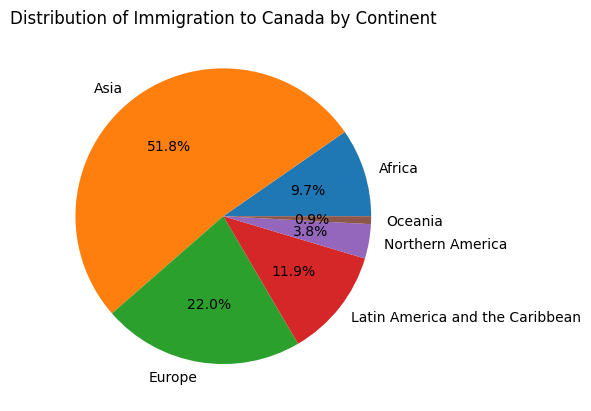

In [77]:
fig, ax = plt.subplots()
ax.pie(df_continent["Total"], labels = continents, autopct = "%1.1f%%")
ax.set_title("Distribution of Immigration to Canada by Continent")
plt.show()

<h2>Sub Plotting</h2>

<p>Total Immigration from 1980 to 2013</p>

In [113]:
years = list(range(1980,2014))
years = list(map(str, years))
years

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [114]:
df_tot = df[years].sum()
df_tot

1980     99137
1981    110563
1982    104271
1983     75550
1984     73417
1985     69978
1986     86048
1987    134771
1988    139306
1989    164432
1990    188054
1991    207509
1992    221687
1993    222049
1994    193665
1995    187712
1996    200085
1997    192885
1998    160727
1999    179818
2000    216712
2001    242643
2002    223111
2003    217297
2004    232083
2005    257457
2006    247057
2007    232405
2008    243047
2009    248768
2010    276956
2011    246194
2012    256222
2013    257537
dtype: int64

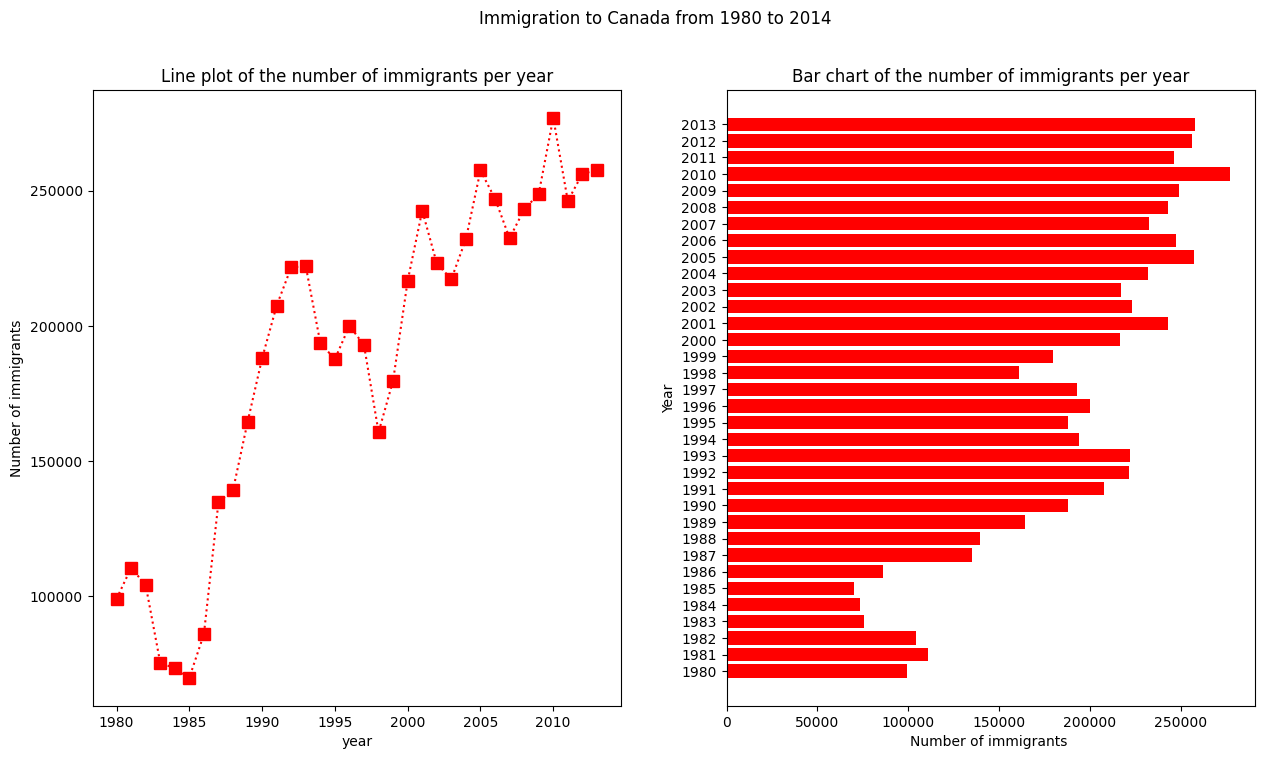

In [134]:
fig = plt.figure(figsize=(15, 8))

ax1 = fig.add_subplot(1,2,1)
ax1.plot(df_tot, marker = "s", markersize = "8", linestyle = "dotted", color = "red")
ax1.set_title("Line plot of the number of immigrants per year")
ax1.set_xlabel("year")
ax1.set_ylabel("Number of immigrants")
ax1.set_xticks(range(0, len(df_tot.index),5))
ax1.set_xticklabels(df_tot.index[::5])

ax2 = fig.add_subplot(1,2,2)
ax2.barh(df_tot.index, df_tot, color = "red")
ax2.set_title("Bar chart of the number of immigrants per year")
ax2.set_xlabel("Number of immigrants ")
ax2.set_ylabel("Year")

fig.suptitle("Immigration to Canada from 1980 to 2014")

plt.show()

<h1>Plotting with Seaborn</h1>

In [144]:
%pip install seaborn

In [145]:
import seaborn as sns

<h2>Count Plot for Categorical Data</h2>

([<matplotlib.axis.XTick at 0xf4eec80>,
 [Text(0, 0, 'Asia'),
  Text(1, 0, 'Europe'),
  Text(2, 0, 'Africa'),
  Text(3, 0, 'Oceania'),
  Text(4, 0, 'N America'),
  Text(5, 0, 'S America')])

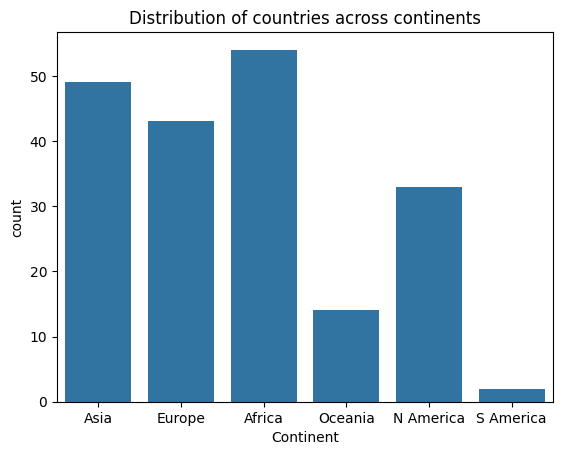

In [158]:
sns.countplot(x = "Continent", data = df)
plt.title("Distribution of countries across continents")
plt.xticks(ticks = list(range(0,6,1)), labels = ["Asia","Europe", "Africa","Oceania", "N America", "S America"])

<h3>Bar Plot</h3>

([<matplotlib.axis.XTick at 0xe04ded0>,
 [Text(0, 0, 'Asia'),
  Text(1, 0, 'Europe'),
  Text(2, 0, 'Africa'),
  Text(3, 0, 'Oceania'),
  Text(4, 0, 'N America'),
  Text(5, 0, 'S America')])

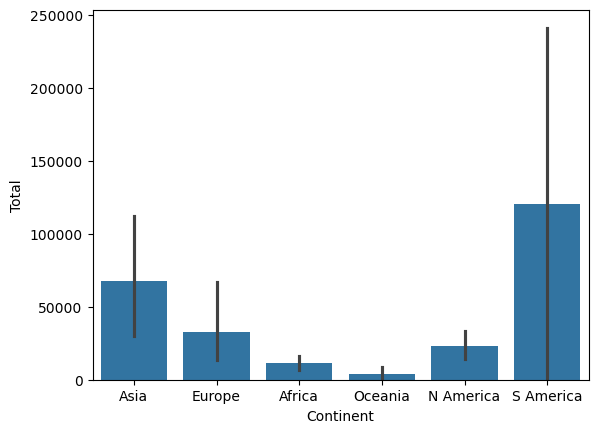

In [169]:
sns.barplot(x = "Continent", y = "Total", data = df)
plt.xticks(ticks = range(0,6,1), labels = ["Asia","Europe", "Africa","Oceania", "N America", "S America"])

In [178]:
df_mean =df.groupby(by ="Continent")["Total"].mean()
df_mean = df_mean.to_frame()
df_mean

,Total
Continent,
Africa,11462.000000
Asia,67710.081633
Europe,32812.720930
Latin America and the Caribbean,23186.303030
Northern America,120571.000000
Oceania,3941.000000


<h3>Regression Plot</h3>

In [189]:
years = list(map(str,range(1980, 2014,1)))
df_bis = df[years].sum()

In [190]:
df_bis

1980     99137
1981    110563
1982    104271
1983     75550
1984     73417
1985     69978
1986     86048
1987    134771
1988    139306
1989    164432
1990    188054
1991    207509
1992    221687
1993    222049
1994    193665
1995    187712
1996    200085
1997    192885
1998    160727
1999    179818
2000    216712
2001    242643
2002    223111
2003    217297
2004    232083
2005    257457
2006    247057
2007    232405
2008    243047
2009    248768
2010    276956
2011    246194
2012    256222
2013    257537
dtype: int64

<AxesSubplot:>

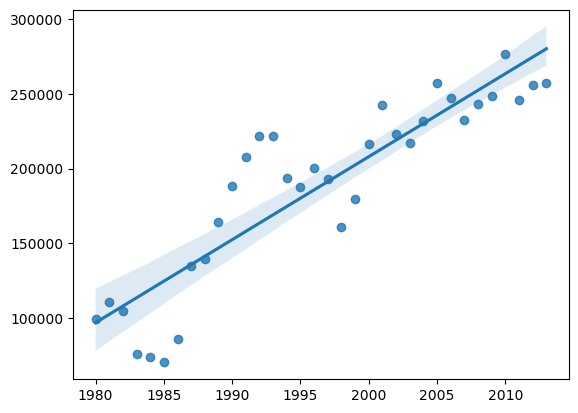

In [198]:
sns.regplot(x = df_bis.index.astype(float), y = df_bis.values)

In [214]:
df_frame = df_bis.to_frame()
df_frame.reset_index(inplace = True)
df_frame.rename(columns = {"index":"year",0: "total"}, inplace = True)
print(df_frame["year"].dtype)
df_frame["year"] = df_frame["year"].astype(float)

object


Text(0.5, 1.1, 'Regression Plot')

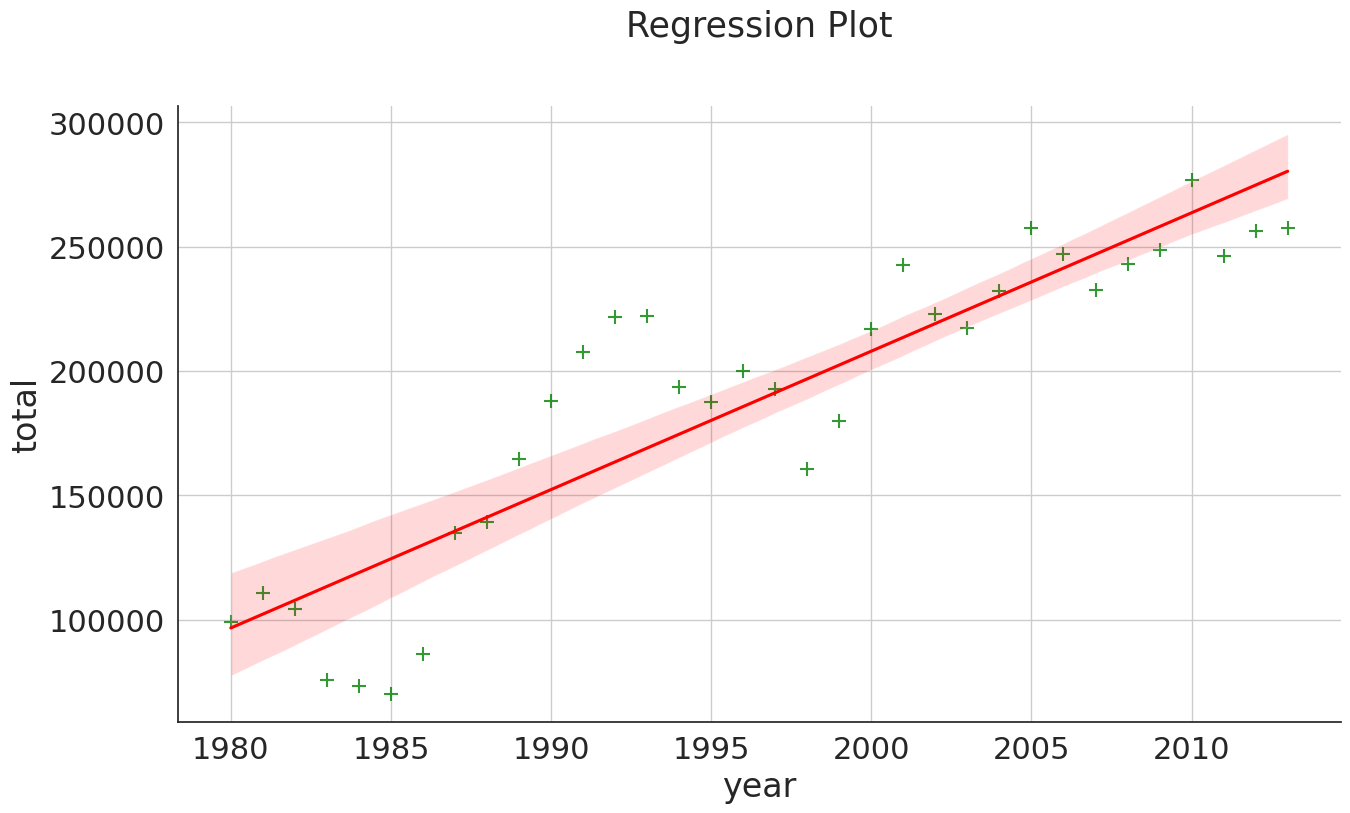

In [249]:
fig = plt.figure(figsize=(15,8))
sns.regplot(x = df_frame["year"], y = df_frame["total"], color = "red", marker = "+", scatter_kws = {"color":"green", "s":100})
sns.set(font_scale = 2)
plt.grid(True)
sns.set_style("white")
sns.despine()
plt.title("Regression Plot", fontsize = 25, y = 1.1)